# Batch Paleomag Data Visualization and Analysis

This notebook loads, parses, and visualizes paleomagnetic data from .hys, .hcr, and .frc files in the LaosBasalts directory. Each section generates a grid of plots for rapid comparison of hysteresis, remanence, and first reversal curve measurements.

## 1. Import Libraries
Import numpy, pandas, matplotlib, and other dependencies for batch paleomag data visualization.

In [1]:
# Import Required Libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

## 2. Load and Parse Hysteresis (.hys) Data
Recursively search all subfolders for .hys files, parse them, and prepare for plotting.

In [2]:
import os
import glob
import pandas as pd

# Recursively find all .hys files in the LaosBasalts directory and subfolders
hys_dir = '/Users/nicolasanderson/Library/Mobile Documents/com~apple~CloudDocs/Caltech Projects/Australasian Impactor/Paleomag Data/VSM data'
hys_files = sorted(glob.glob(os.path.join(hys_dir, '**', '*.hys', '*.hcr', '*.frc'), recursive=True))
print(f"Found {len(hys_files)} .hys files.")

Found 0 .hys files.


## 3. Plot Hysteresis Loops (.hys files)
Display a grid of hysteresis loops for all found .hys files (recursively), with 3 columns and as many rows as needed.

In [3]:
import matplotlib.pyplot as plt

# Set grid size: always 3 columns, rows depend on file count
n_cols = 3
n_rows = (len(hys_files) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
axes = axes.flatten()

for idx, hys_file in enumerate(hys_files):
    with open(hys_file, 'r') as f:
        lines = f.readlines()
    data_start = None
    for i, line in enumerate(lines):
        if 'Adjusted' in line and 'Adjusted' in line:
            data_start = i + 2
            break
    if data_start is None:
        continue
    data = []
    for line in lines[data_start:]:
        parts = line.strip().split(',')
        if len(parts) == 4:
            try:
                field = float(parts[2])
                moment = float(parts[3])
                data.append([field, moment])
            except ValueError:
                continue
    hys_df = pd.DataFrame(data, columns=['Field_T', 'Moment_Am2']).dropna()
    if hys_df.empty:
        continue
    ax = axes[idx]
    ax.plot(hys_df['Field_T'], hys_df['Moment_Am2'], color='navy', linewidth=1)
    ax.set_title(os.path.basename(hys_file), fontsize=10)
    ax.set_xlabel('Field (T)', fontsize=8)
    ax.set_ylabel('Moment (Am²)', fontsize=8)
    ax.grid(True, alpha=0.3)
for ax in axes[len(hys_files):]:
    ax.axis('off')
plt.tight_layout()
plt.suptitle('Hysteresis Loops (.hys files)', fontsize=18)
plt.show()

ValueError: Number of rows must be a positive integer, not 0

<Figure size 1500x0 with 0 Axes>

## 4. Plot Remanence Curves (.hcr files)
Display a grid of remanence curves for all found .hcr files (recursively), with 3 columns and as many rows as needed.

Found 19 .hcr files.


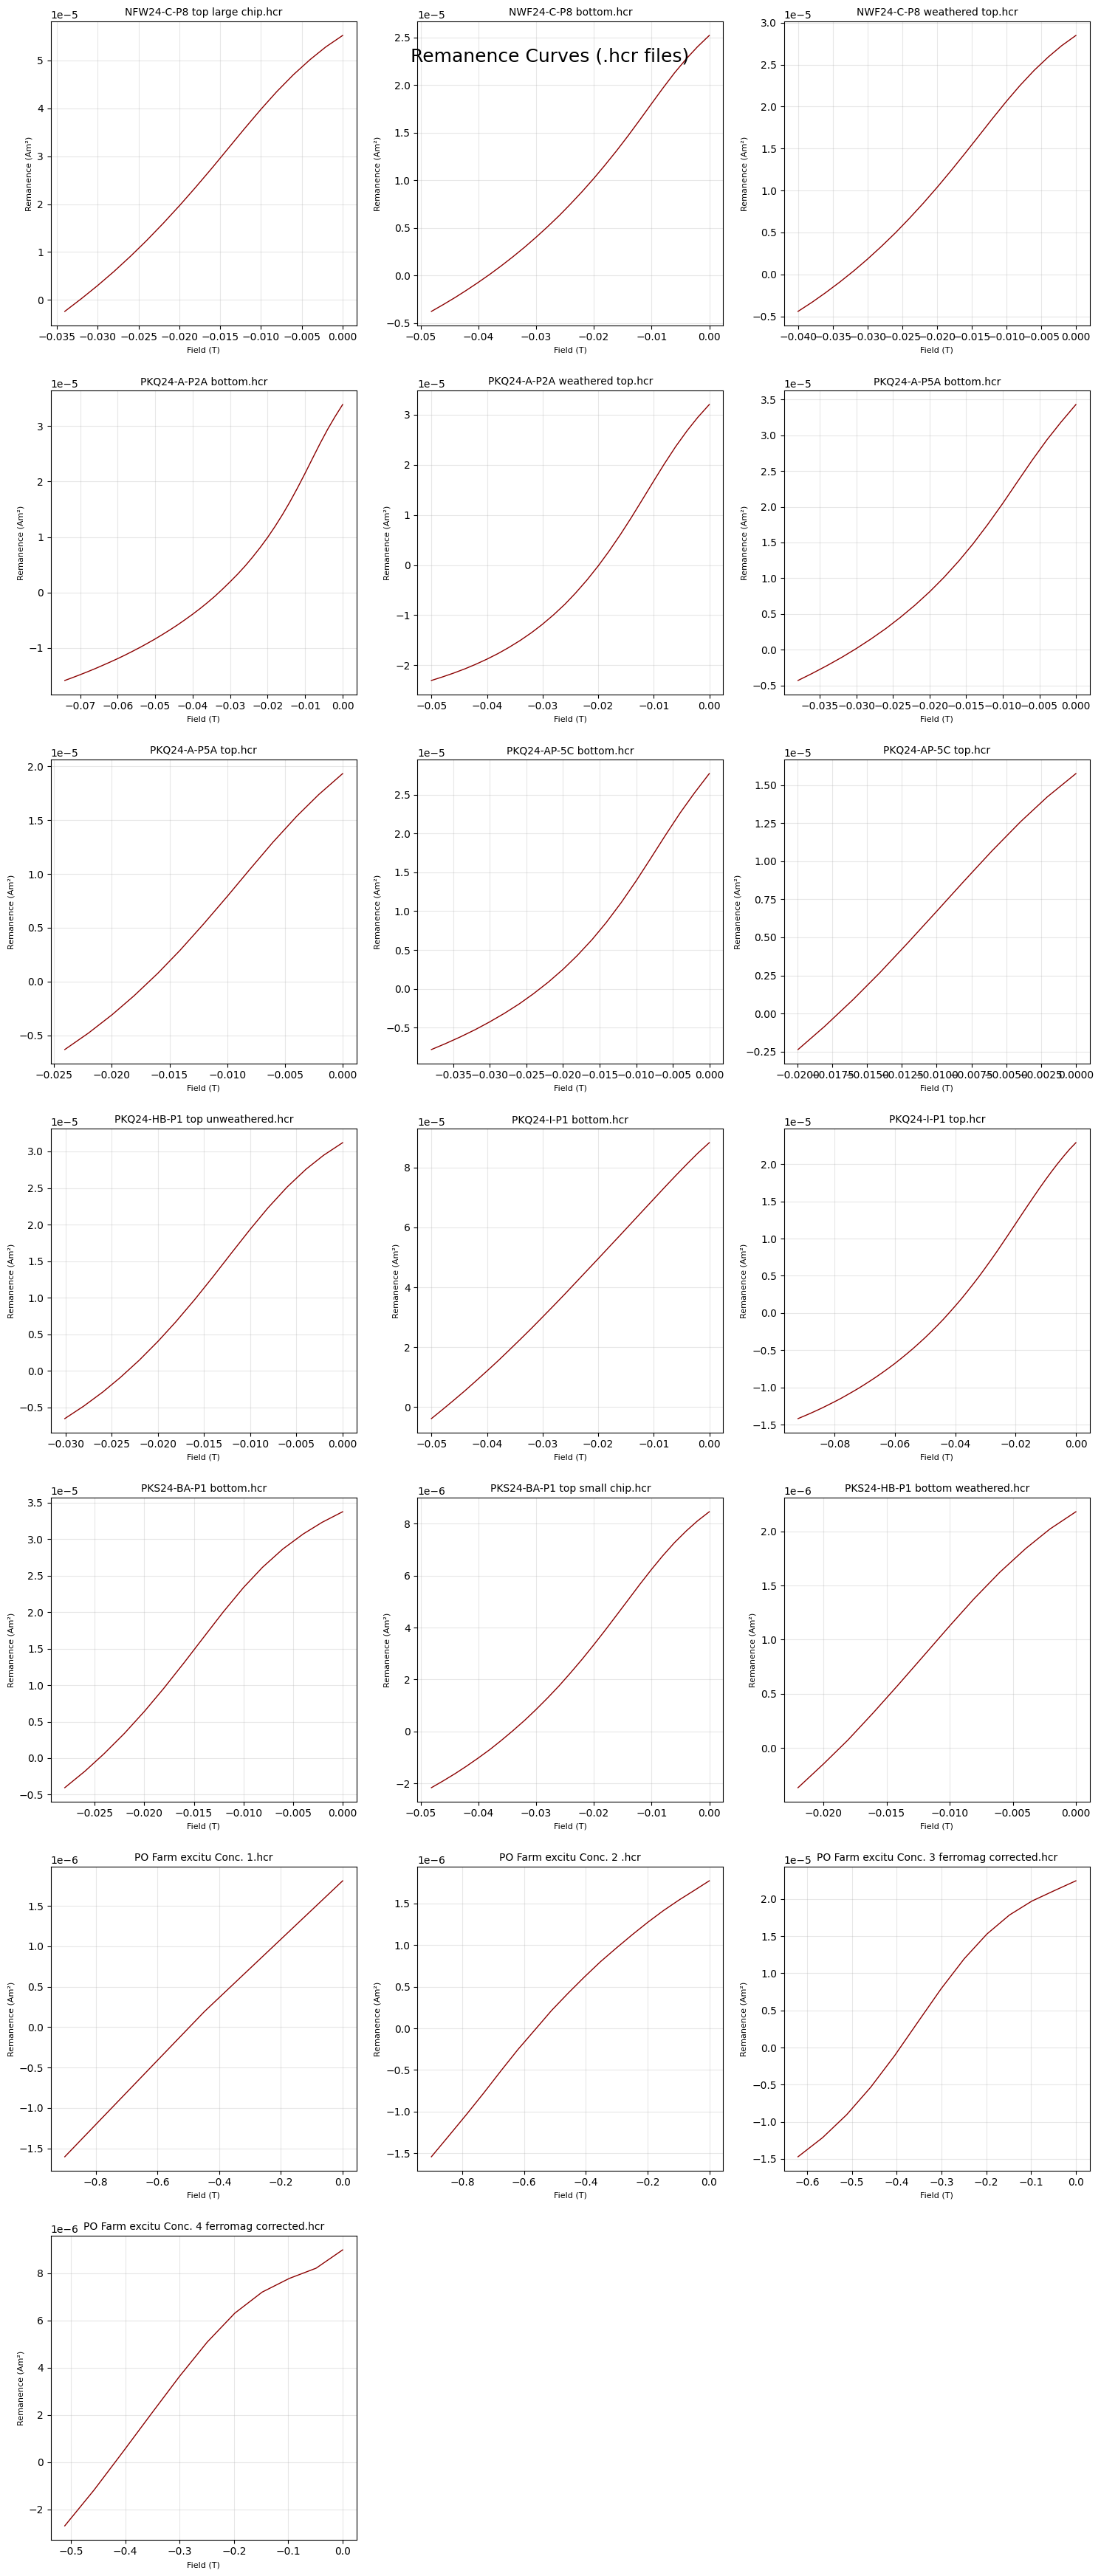

In [4]:
import re

# Recursively find all .hcr files in the LaosBasalts directory and subfolders
hcr_files = sorted(glob.glob(os.path.join(hys_dir, '**', '*.hcr'), recursive=True))
print(f"Found {len(hcr_files)} .hcr files.")

n_cols = 3
n_rows = (len(hcr_files) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
axes = axes.flatten()

for idx, hcr_file in enumerate(hcr_files):
    with open(hcr_file, 'r') as f:
        lines = f.readlines()
    data_start = None
    for i, line in enumerate(lines):
        if 'Field' in line and 'Remanence' in line:
            data_start = i + 1
            break
    if data_start is None:
        continue
    data = []
    for line in lines[data_start:]:
        line = line.strip()
        if not line or not re.match(r'[-+0-9Ee.,]+', line):
            continue
        parts = re.split(r'[ ,]+', line)
        if len(parts) >= 2:
            try:
                field = float(parts[0])
                remanence = float(parts[1])
                data.append([field, remanence])
            except ValueError:
                continue
    hcr_df = pd.DataFrame(data, columns=['Field_T', 'Remanence_Am2']).dropna()
    if hcr_df.empty:
        continue
    ax = axes[idx]
    ax.plot(hcr_df['Field_T'], hcr_df['Remanence_Am2'], color='darkred', linewidth=1)
    ax.set_title(os.path.basename(hcr_file), fontsize=10)
    ax.set_xlabel('Field (T)', fontsize=8)
    ax.set_ylabel('Remanence (Am²)', fontsize=8)
    ax.grid(True, alpha=0.3)
for ax in axes[len(hcr_files):]:
    ax.axis('off')
plt.tight_layout()
plt.suptitle('Remanence Curves (.hcr files)', fontsize=18)
plt.show()

## 5. Plot First Reversal Curves (.frc files)
This section finds all .frc files in the LaosBasalts directory, parses the first reversal curve data, and displays a 3-column by 10-row grid of FRC plots for rapid comparison.

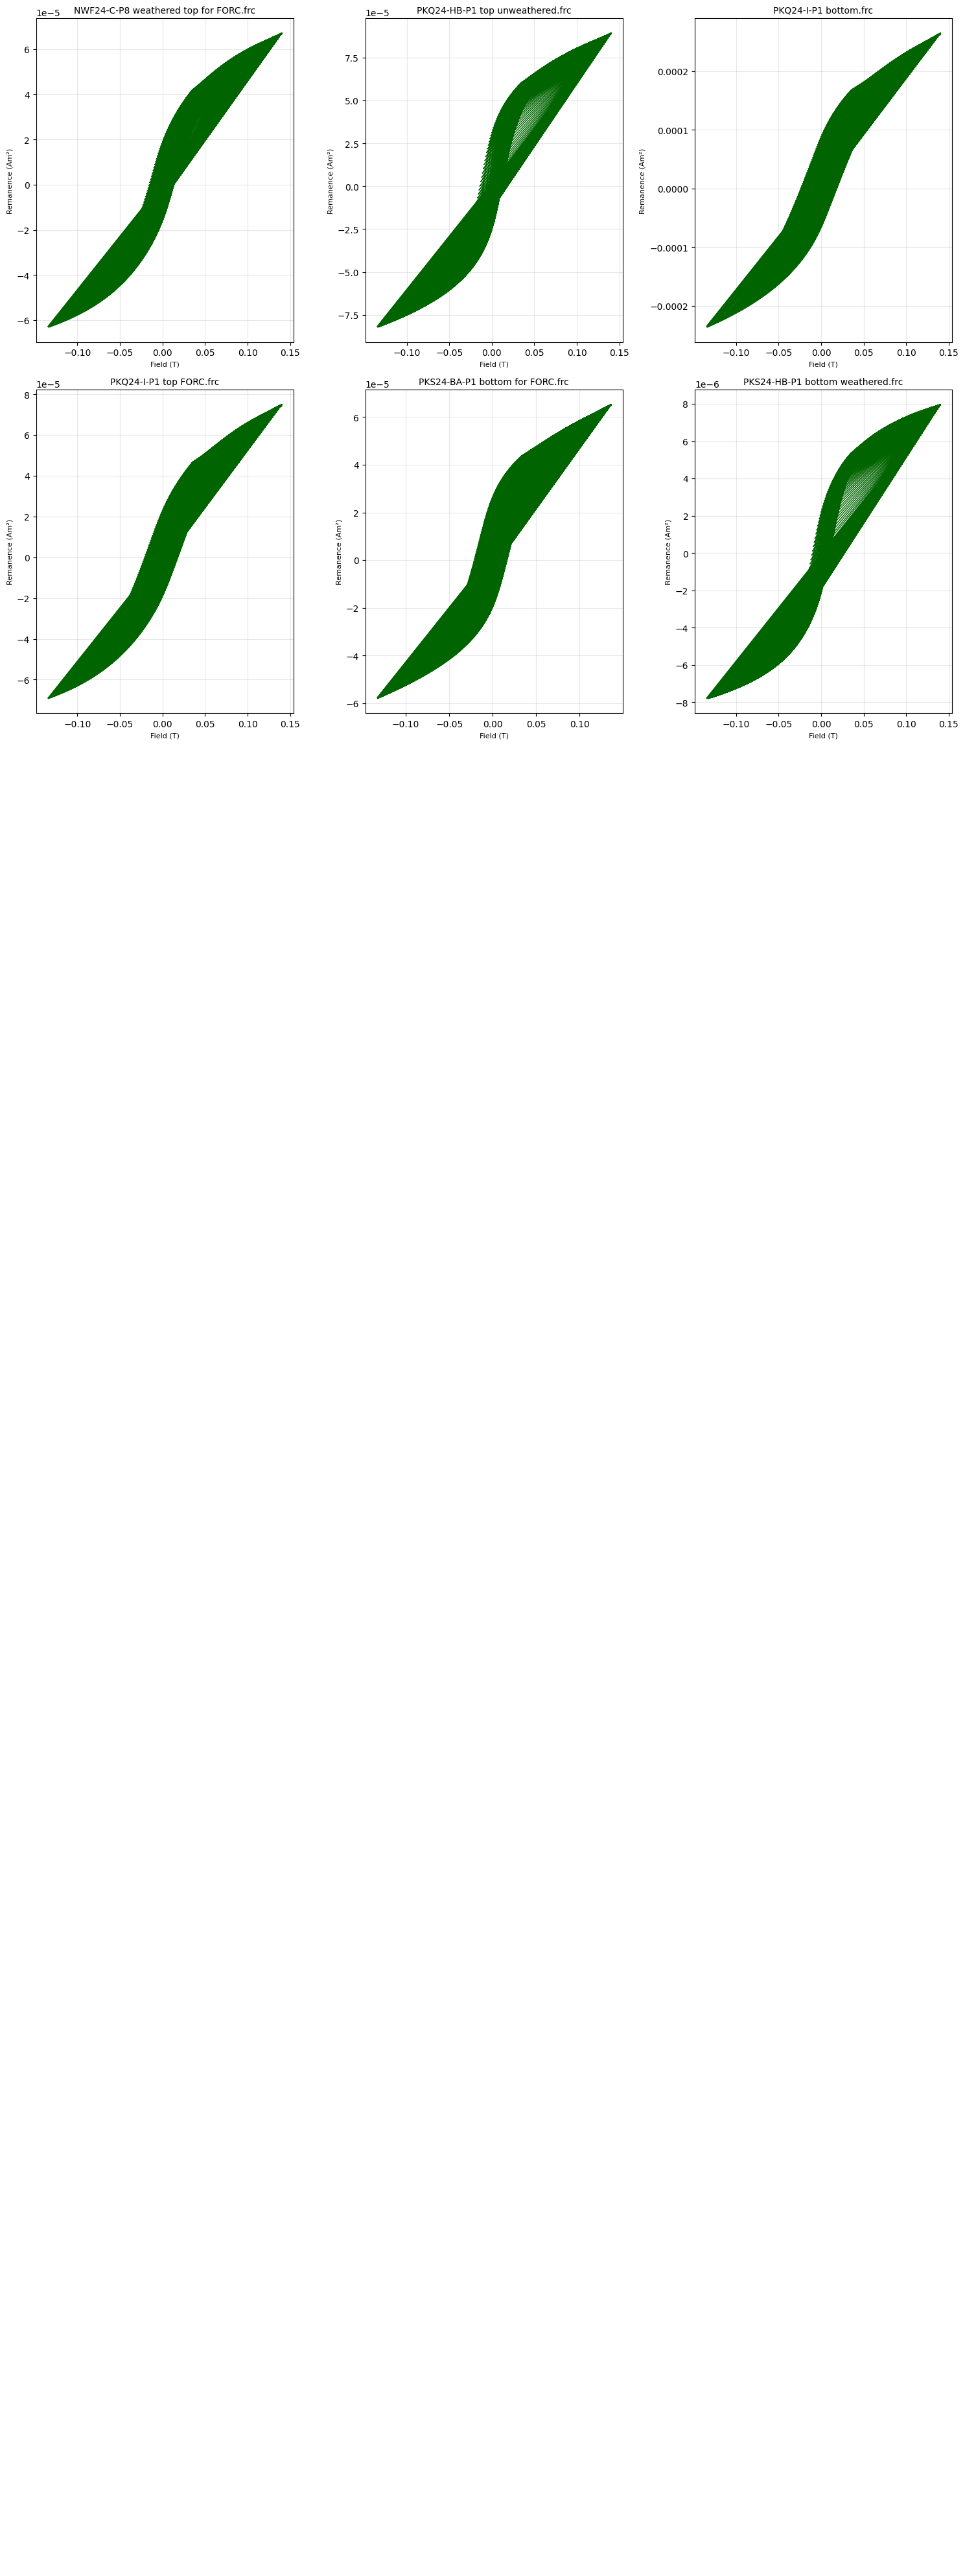

In [5]:
# Process and plot all .frc files in the directory
frc_files = sorted(glob.glob(os.path.join(hys_dir, '**', '*.frc')))
n_files_frc = min(len(frc_files), 30)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 40))
axes = axes.flatten()

for idx, frc_file in enumerate(frc_files[:n_files_frc]):
    with open(frc_file, 'r') as f:
        lines = f.readlines()

    # Find where the data block starts (look for header line with 'Field' and 'Remanence')
    data_start = None
    for i, line in enumerate(lines):
        if re.match(r'\s*Field\s+Moment', line):
            data_start = i + 1
            break

    if data_start is None:
        continue  # skip files without proper header

    data = []
    for line in lines[data_start:]:
        line = line.strip()
        if not line or not re.match(r'[-+0-9Ee.,]+', line):
            continue
        parts = re.split(r'[ ,]+', line)
        if len(parts) >= 2:
            try:
                field = float(parts[0])
                remanence = float(parts[1])
                data.append([field, remanence])
            except ValueError:
                continue

    if not data:
        continue

    frc_df = pd.DataFrame(data, columns=['Field_T', 'Remanence_Am2']).dropna()
    if frc_df.empty:
        continue

    ax = axes[idx]
    ax.plot(frc_df['Field_T'], frc_df['Remanence_Am2'], color='darkgreen', linewidth=1)
    ax.set_title(os.path.basename(frc_file), fontsize=10)
    ax.set_xlabel('Field (T)', fontsize=8)
    ax.set_ylabel('Remanence (Am²)', fontsize=8)
    ax.grid(True, alpha=0.3)

# Hide unused subplots
for ax in axes[n_files_frc:]:
    ax.axis('off')

plt.tight_layout()
plt.show()

# Paleomagnetic Data Analysis: Common Tests and Interpretations

This notebook loads, parses, and analyzes .hys, .hcr, and .frc files. It performs standard paleomagnetic tests to help determine domain state, magnetic stability, and interactions.

## 1. Discover and Load Data

Recursively search for .hys, .hcr, and .frc files. Prepare lists for analysis.

In [6]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

# Set root directory for recursive search
root_dir = '/Users/nicolasanderson/Library/Mobile Documents/com~apple~CloudDocs/Caltech Projects/Australasian Impactor/Paleomag Data/VSM data'

# Find all files recursively
hys_files = sorted(glob.glob(os.path.join(root_dir, '**', '*.hys'), recursive=True))
hcr_files = sorted(glob.glob(os.path.join(root_dir, '**', '*.hcr'), recursive=True))
frc_files = sorted(glob.glob(os.path.join(root_dir, '**', '*.frc'), recursive=True))

print(f"Found {len(hys_files)} .hys, {len(hcr_files)} .hcr, {len(frc_files)} .frc files.")

Found 26 .hys, 19 .hcr, 6 .frc files.


## 2. Hysteresis Analysis (.hys)

Extract Ms, Mr, Hc, plot hysteresis loop, compute ratios (Mr/Ms, Hcr/Hc), and generate Day plot for domain state interpretation.

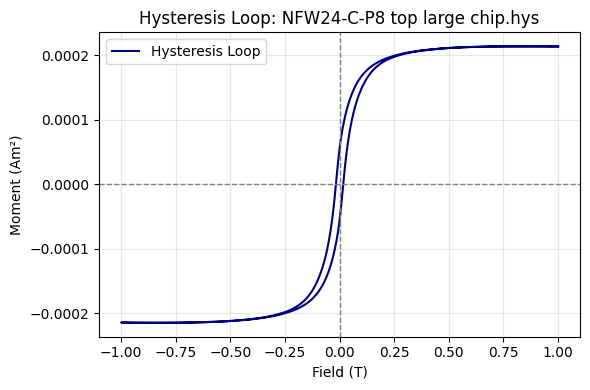

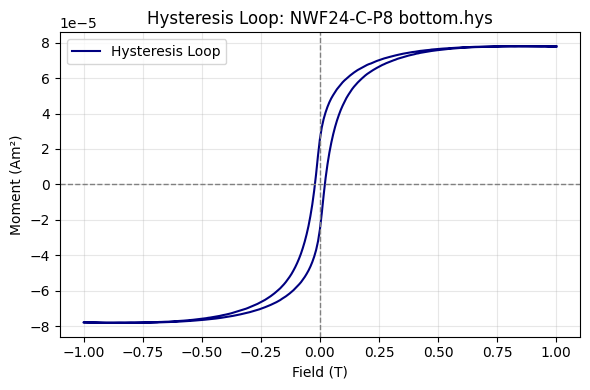

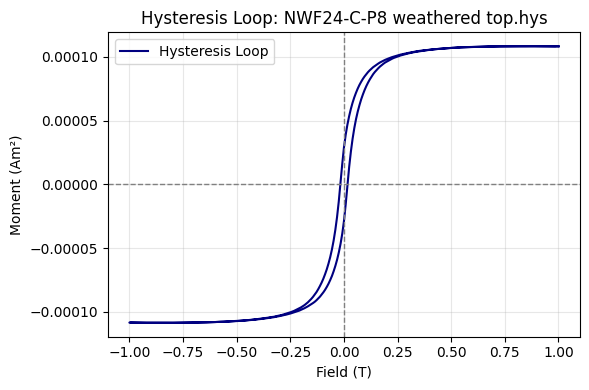

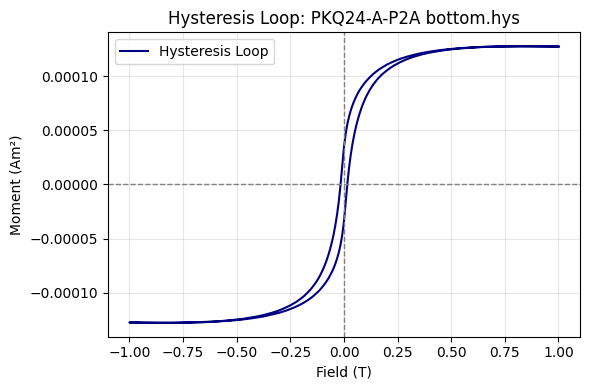

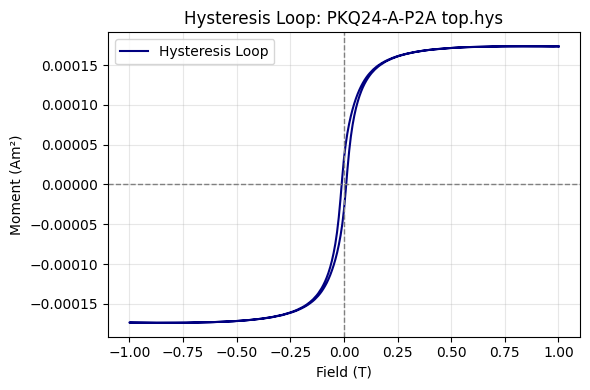

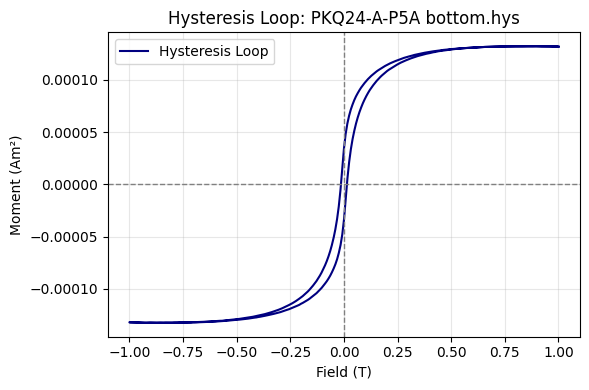

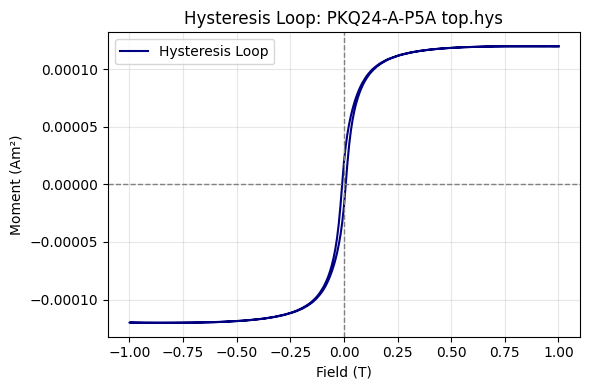

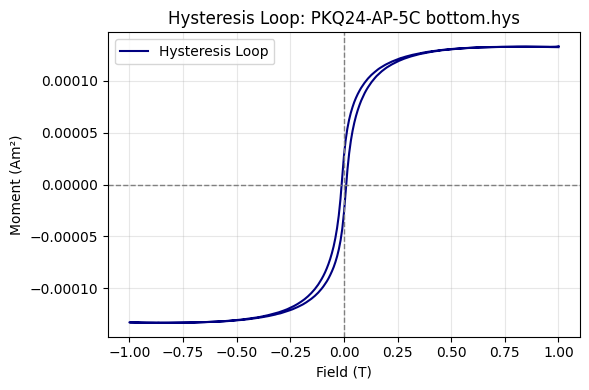

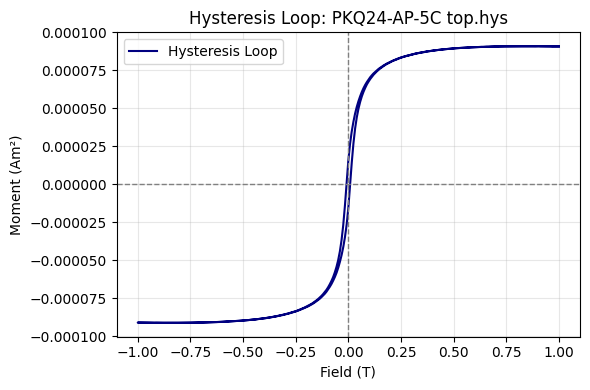

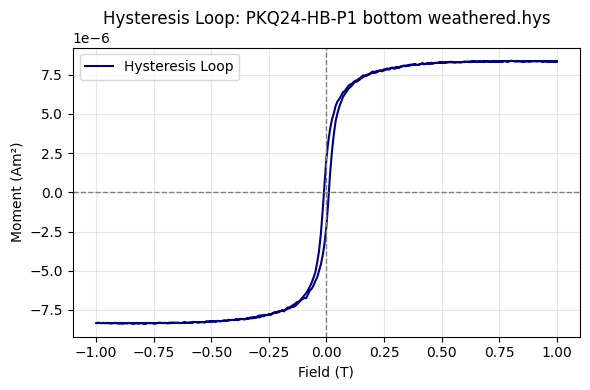

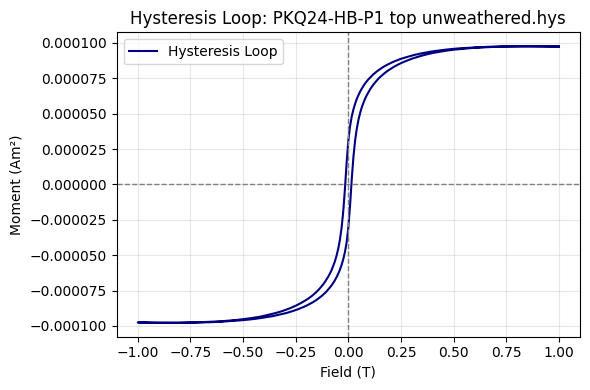

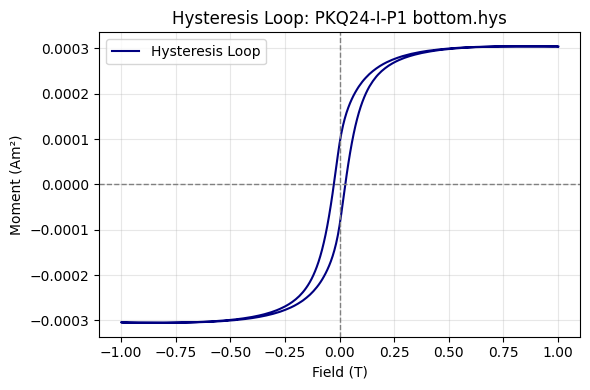

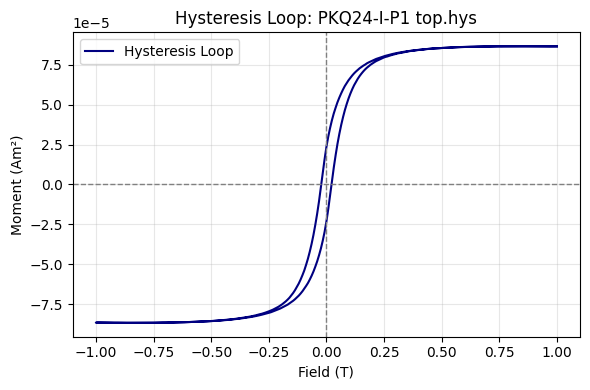

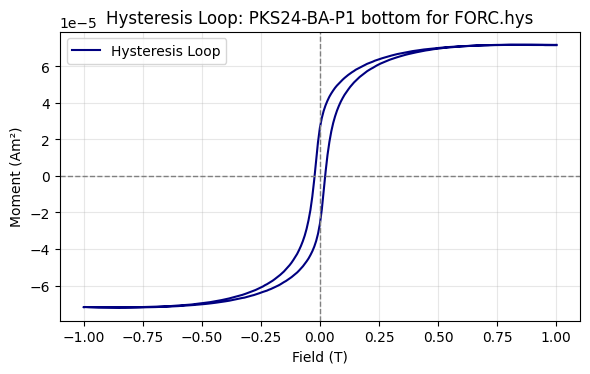

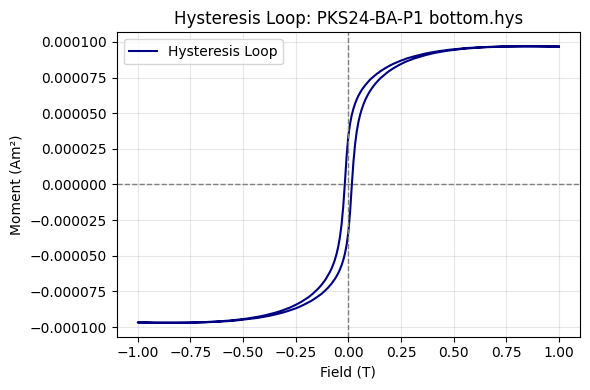

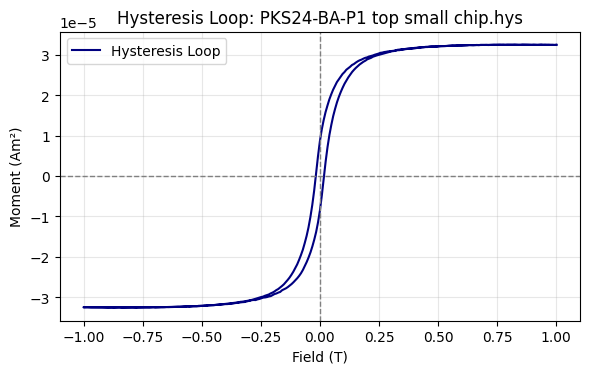

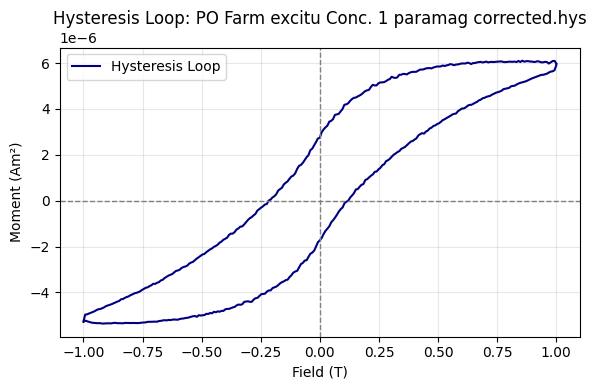

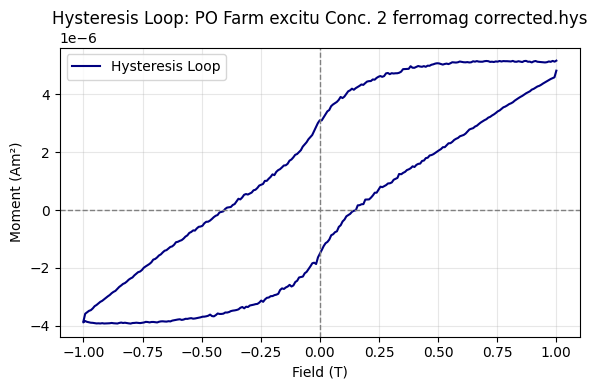

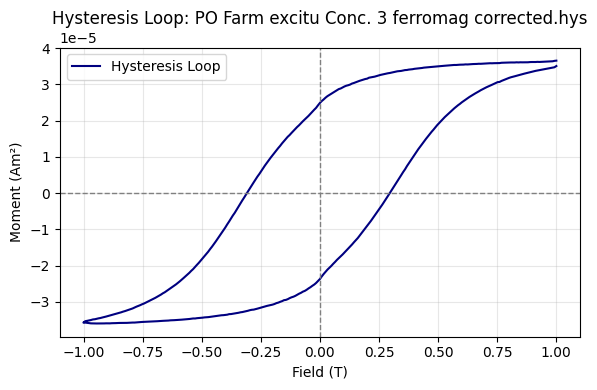

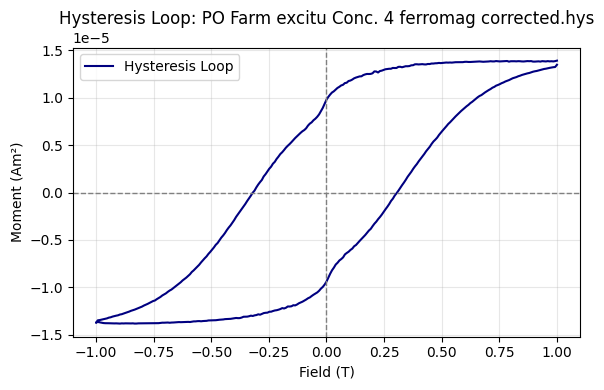

In [7]:
# Analyze all .hys files and collect key parameters for Day plot
hys_results = []
for hys_file in hys_files:
    with open(hys_file, 'r') as f:
        lines = f.readlines()
    data_start = None
    for i, line in enumerate(lines):
        if 'Adjusted' in line and 'Adjusted' in line:
            data_start = i + 2
            break
    if data_start is None:
        continue
    data = []
    for line in lines[data_start:]:
        parts = line.strip().split(',')
        if len(parts) == 4:
            try:
                field = float(parts[2])
                moment = float(parts[3])
                data.append([field, moment])
            except ValueError:
                continue
    df = pd.DataFrame(data, columns=['Field_T', 'Moment_Am2']).dropna()
    if df.empty:
        continue
    # Extract parameters
    H = df['Field_T']
    M = df['Moment_Am2']
    Ms = M.max()
    Mr = M[np.isclose(H, 0)].max() if not M[np.isclose(H, 0)].empty else np.nan
    Hc = H[np.argmin(np.abs(M))] if not M.empty else np.nan
    # Store for Day plot
    hys_results.append({'file': os.path.basename(hys_file), 'Ms': Ms, 'Mr': Mr, 'Hc': Hc})
    # Plot hysteresis loop
    plt.figure(figsize=(6,4))
    plt.plot(H, M, label='Hysteresis Loop', color='navy')
    plt.axhline(0, color='grey', linestyle='--', linewidth=1)
    plt.axvline(0, color='grey', linestyle='--', linewidth=1)
    plt.xlabel('Field (T)')
    plt.ylabel('Moment (Am²)')
    plt.title(f'Hysteresis Loop: {os.path.basename(hys_file)}')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [8]:
# Generate Day plot (Mr/Ms vs Hcr/Hc) if .hcr data is available
day_results = []
for hys in hys_results:
    # Find matching .hcr file by name
    base = hys['file'].split('.')[0]
    hcr_file = next((f for f in hcr_files if base in os.path.basename(f)), None)
    Hcr = np.nan
    if hcr_file:
        with open(hcr_file, 'r') as f:
            lines = f.readlines()
        data_start = None
        for i, line in enumerate(lines):
            if 'Field' in line and 'Remanence' in line:
                data_start = i + 1
                break
        if data_start is not None:
            data = []
            for line in lines[data_start:]:
                line = line.strip()
                if not line or not re.match(r'[-+0-9Ee.,]+', line):
                    continue
                parts = re.split(r'[ ,]+', line)
                if len(parts) >= 2:
                    try:
                        field = float(parts[0])
                        remanence = float(parts[1])
                        data.append([field, remanence])
                    except ValueError:
                        continue
            df = pd.DataFrame(data, columns=['Field_T', 'Remanence_Am2']).dropna()
            if not df.empty:
                # Hcr is field where remanence crosses zero
                Hcr = df['Field_T'][np.argmin(np.abs(df['Remanence_Am2']))]
    if hys['Ms'] and hys['Hc'] and Hcr and hys['Mr'] and hys['Ms'] > 0 and hys['Hc'] > 0 and Hcr > 0:
        day_results.append({'file': hys['file'], 'Mr/Ms': hys['Mr']/hys['Ms'], 'Hcr/Hc': Hcr/hys['Hc']})
if day_results:
    plt.figure(figsize=(6,6))
    plt.scatter([r['Hcr/Hc'] for r in day_results], [r['Mr/Ms'] for r in day_results], color='orange')
    for r in day_results:
        plt.text(r['Hcr/Hc'], r['Mr/Ms'], r['file'], fontsize=8)
    plt.xlabel('Hcr/Hc')
    plt.ylabel('Mr/Ms')
    plt.title('Day Plot: Domain State Analysis')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

## 3. Remanence Analysis (.hcr)

Plot IRM acquisition curves, extract Hcr, and compare to Hc for domain state inference.

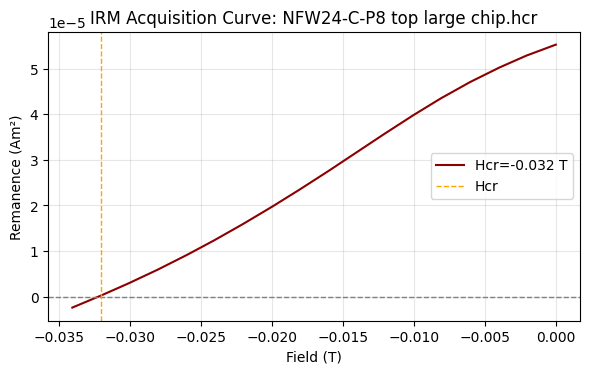

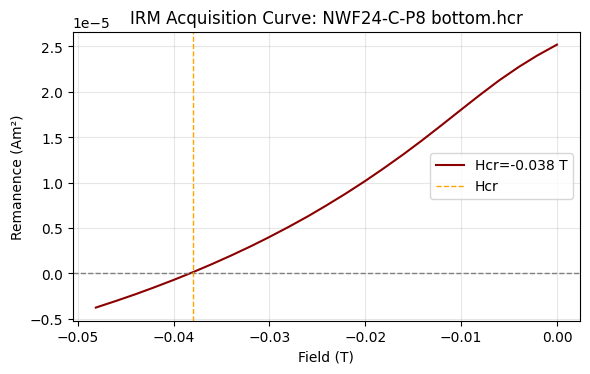

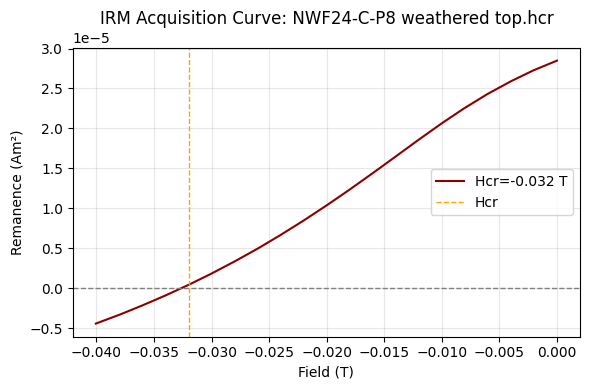

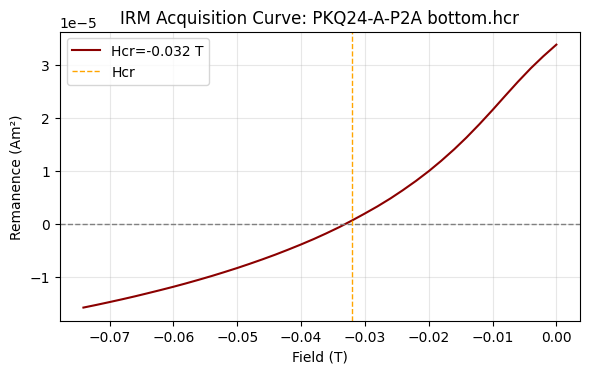

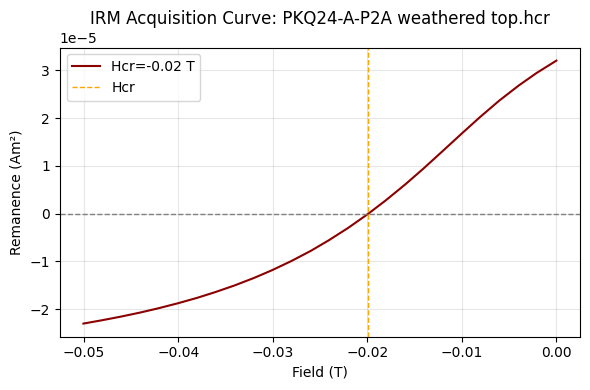

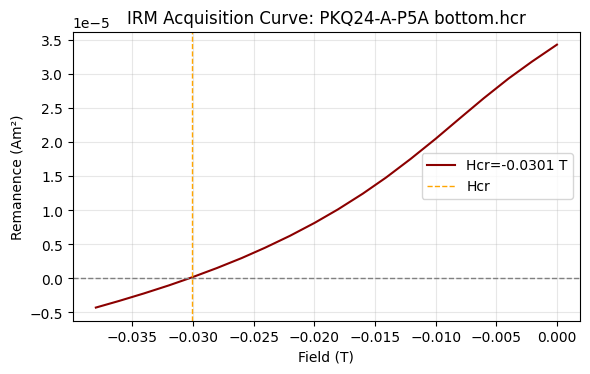

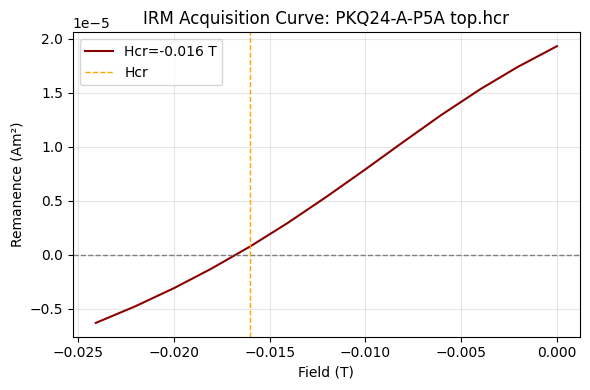

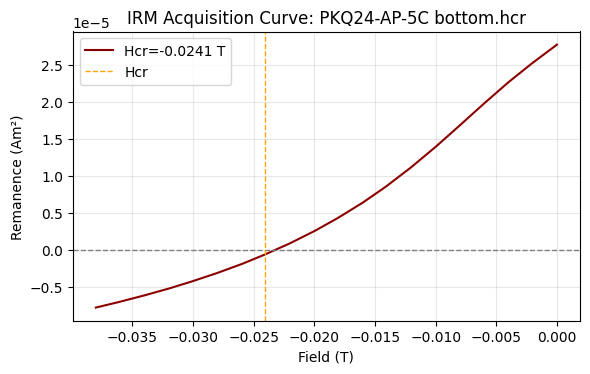

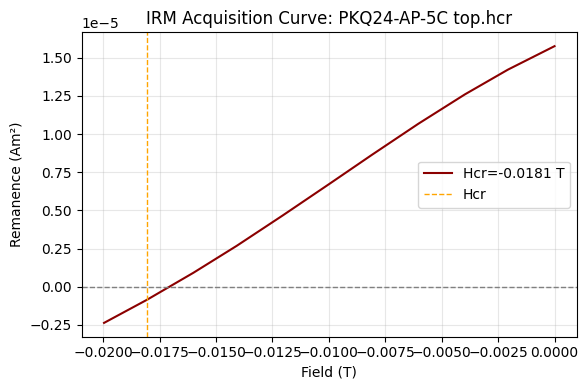

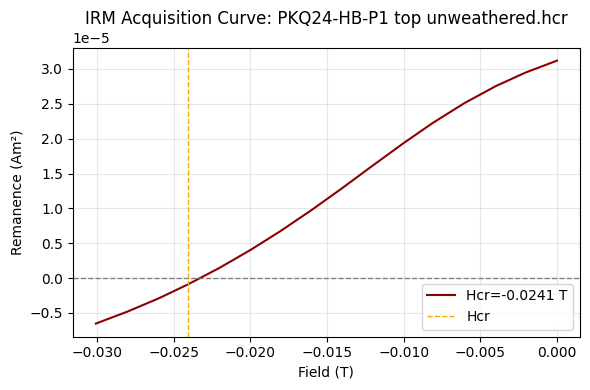

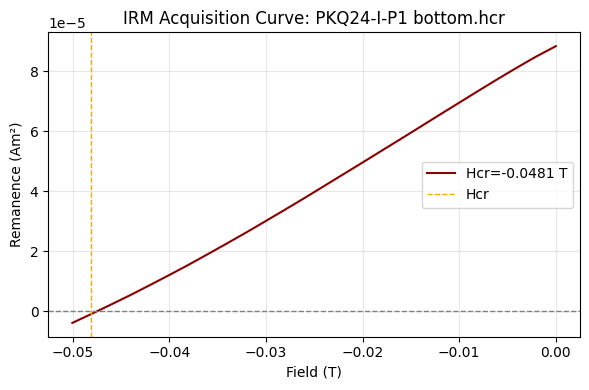

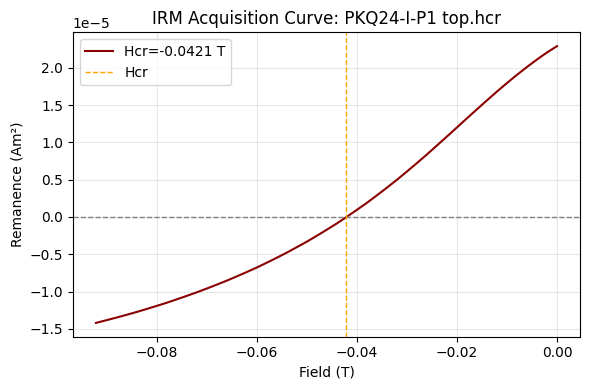

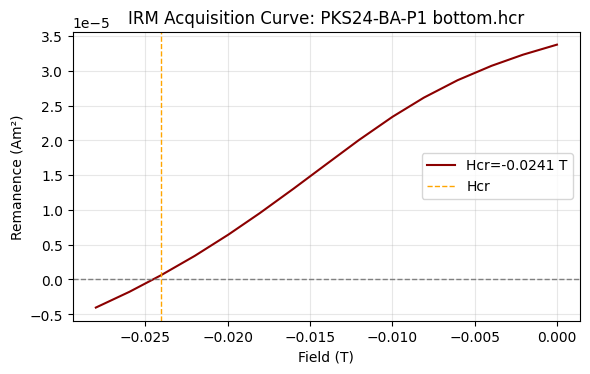

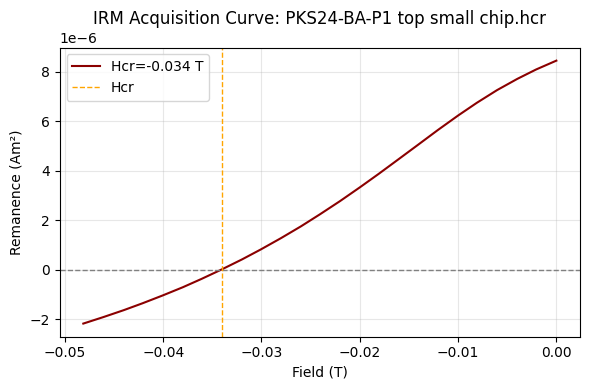

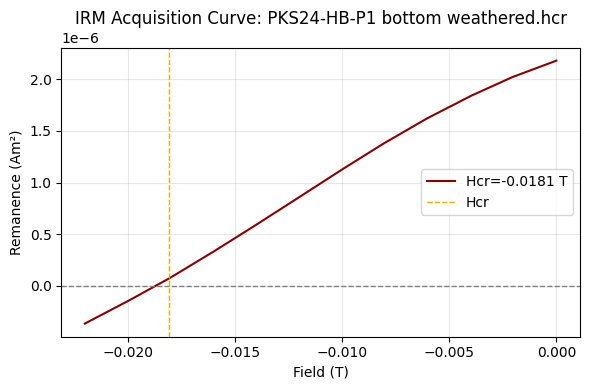

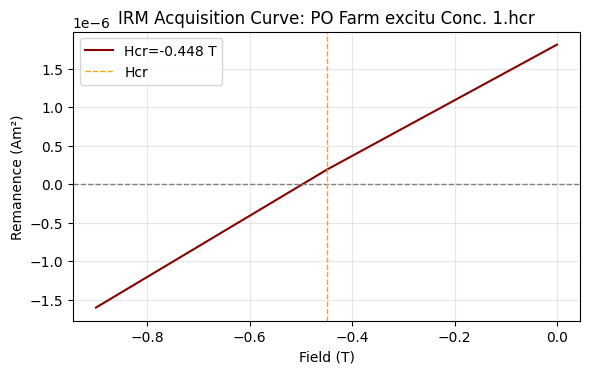

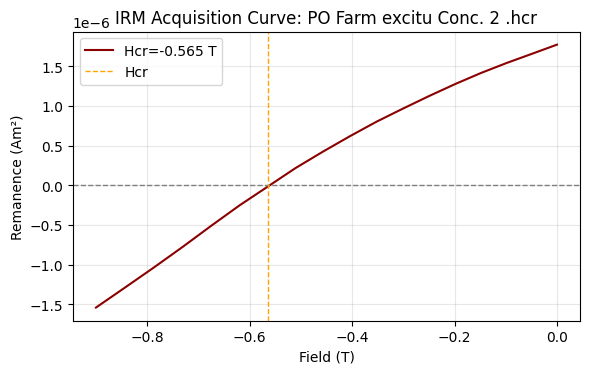

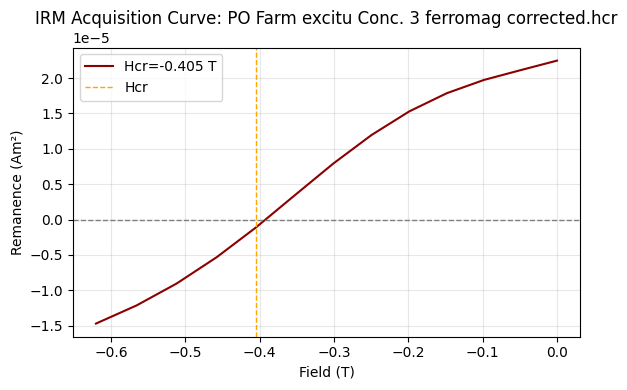

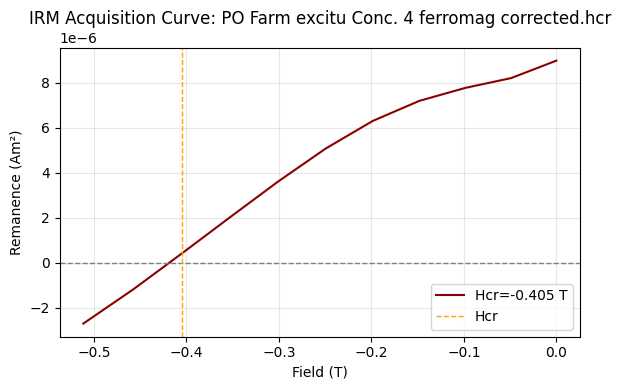

In [9]:
# Plot IRM acquisition curves and extract Hcr for each .hcr file
for hcr_file in hcr_files:
    with open(hcr_file, 'r') as f:
        lines = f.readlines()
    data_start = None
    for i, line in enumerate(lines):
        if 'Field' in line and 'Remanence' in line:
            data_start = i + 1
            break
    if data_start is None:
        continue
    data = []
    for line in lines[data_start:]:
        line = line.strip()
        if not line or not re.match(r'[-+0-9Ee.,]+', line):
            continue
        parts = re.split(r'[ ,]+', line)
        if len(parts) >= 2:
            try:
                field = float(parts[0])
                remanence = float(parts[1])
                data.append([field, remanence])
            except ValueError:
                continue
    df = pd.DataFrame(data, columns=['Field_T', 'Remanence_Am2']).dropna()
    if df.empty:
        continue
    Hcr = df['Field_T'][np.argmin(np.abs(df['Remanence_Am2']))]
    plt.figure(figsize=(6,4))
    plt.plot(df['Field_T'], df['Remanence_Am2'], color='darkred', label=f'Hcr={Hcr:.3g} T')
    plt.axhline(0, color='grey', linestyle='--', linewidth=1)
    plt.axvline(Hcr, color='orange', linestyle='--', linewidth=1, label='Hcr')
    plt.xlabel('Field (T)')
    plt.ylabel('Remanence (Am²)')
    plt.title(f'IRM Acquisition Curve: {os.path.basename(hcr_file)}')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

## 4. First Reversal Curve Analysis (.frc)

Plot raw FRC curves and discuss interpretation for domain state and interaction.

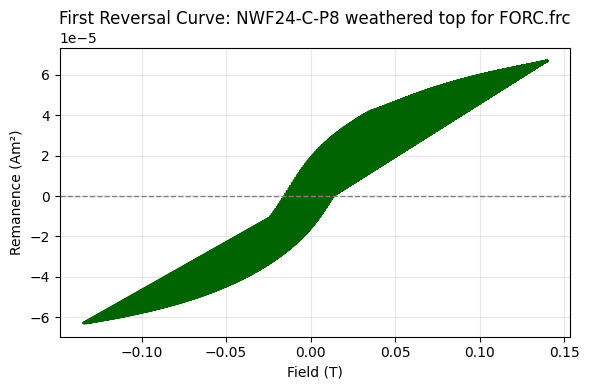

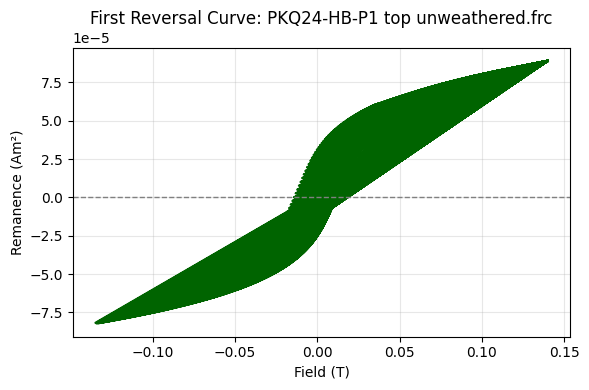

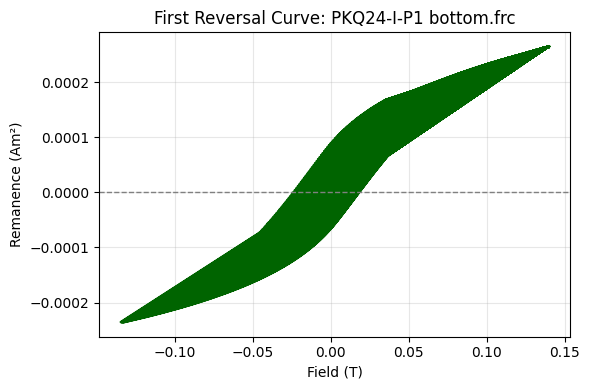

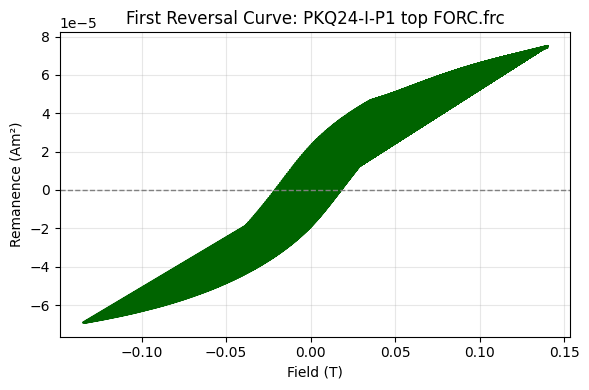

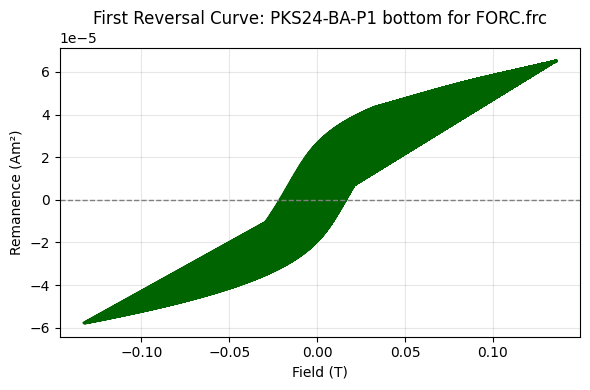

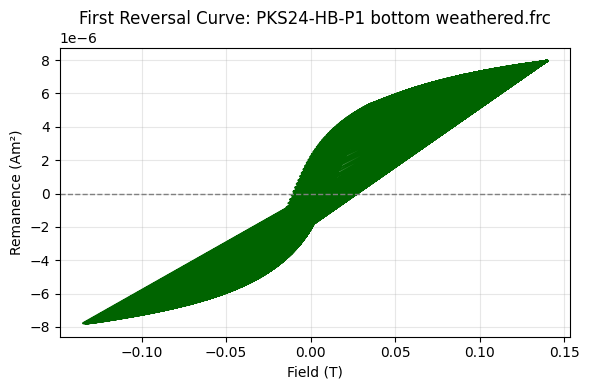

In [10]:
# Plot raw FRC curves for each .frc file
for frc_file in frc_files:
    with open(frc_file, 'r') as f:
        lines = f.readlines()
    data_start = None
    for i, line in enumerate(lines):
        if 'Field' in line and ('Moment' in line or 'Remanence' in line):
            data_start = i + 1
            break
    if data_start is None:
        continue
    data = []
    for line in lines[data_start:]:
        line = line.strip()
        if not line or not re.match(r'[-+0-9Ee.,]+', line):
            continue
        parts = re.split(r'[ ,]+', line)
        if len(parts) >= 2:
            try:
                field = float(parts[0])
                remanence = float(parts[1])
                data.append([field, remanence])
            except ValueError:
                continue
    df = pd.DataFrame(data, columns=['Field_T', 'Remanence_Am2']).dropna()
    if df.empty:
        continue
    plt.figure(figsize=(6,4))
    plt.plot(df['Field_T'], df['Remanence_Am2'], color='darkgreen')
    plt.axhline(0, color='grey', linestyle='--', linewidth=1)
    plt.xlabel('Field (T)')
    plt.ylabel('Remanence (Am²)')
    plt.title(f'First Reversal Curve: {os.path.basename(frc_file)}')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()